Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

Step 2: Load Datasets

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

print(nav.head())

print(performance.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct  

Step 3: Check Columns

In [3]:
print(nav.columns.tolist())

print(performance.columns.tolist())

['amfi_code', 'date', 'nav']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


Step 4: Convert Date

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

Step 5: Compute Daily Returns

In [5]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


Step 6: Plot Daily Return Distribution

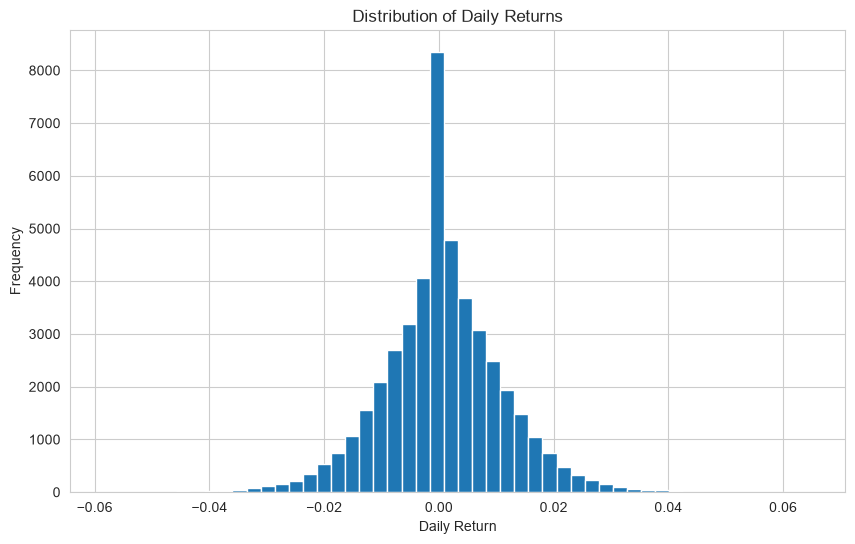

In [6]:
plt.hist(nav["daily_return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [7]:
plt.savefig("../dashboard/charts/daily_return_distribution.png")

<Figure size 1000x600 with 0 Axes>

Step 7: CAGR Table

In [8]:
cagr = performance[
[
    "scheme_name",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]
]

cagr.head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


Step 8: Sharpe Ratio Ranking

In [9]:
performance = performance.sort_values(
    "sharpe_ratio",
    ascending=False
)

performance[
[
    "scheme_name",
    "sharpe_ratio"
]
].head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


Step 9: Plot Top Sharpe Funds

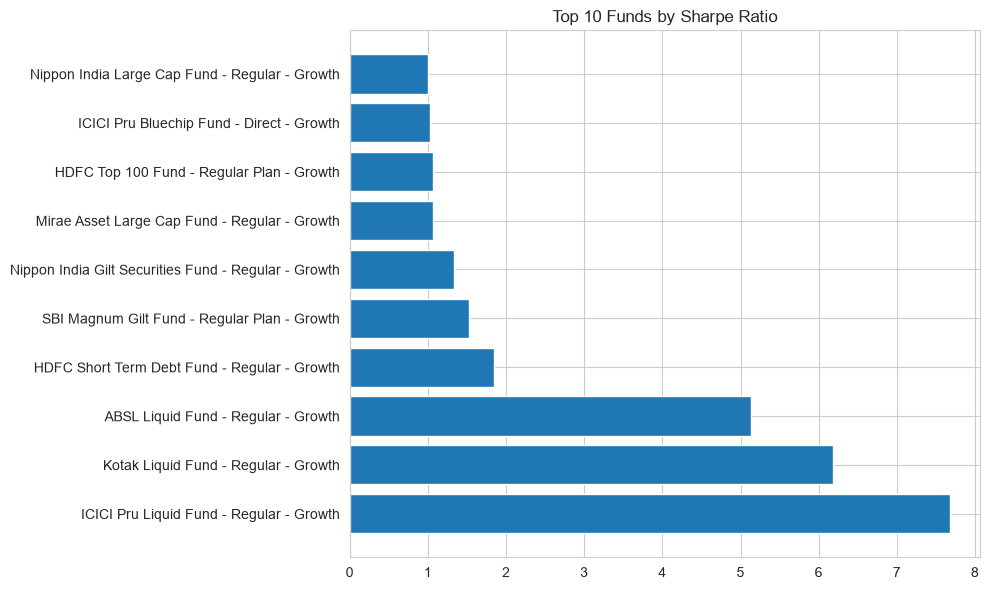

In [10]:
top = performance.head(10)

plt.barh(
    top["scheme_name"],
    top["sharpe_ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig("../dashboard/charts/top_sharpe_ratio.png")

plt.show()

Step 10: Sortino Ranking

In [11]:
performance.sort_values(
    "sortino_ratio",
    ascending=False
)[
[
"scheme_name",
"sortino_ratio"
]
].head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


Step 11: Alpha Ranking

In [12]:
performance.sort_values(
    "alpha",
    ascending=False
)[
[
"scheme_name",
"alpha"
]
].head(10)

,scheme_name,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,1.91
22,Kotak Flexicap Fund - Regular - Growth,1.85
14,ICICI Pru Liquid Fund - Regular - Growth,1.85
29,ABSL Small Cap Fund - Regular - Growth,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,1.82
18,Nippon India ETF Nifty 50 BeES,1.80
33,UTI Flexi Cap Fund - Regular - Growth,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70


Step 12: Beta Ranking

In [13]:
performance.sort_values(
    "beta"
)[
[
"scheme_name",
"beta"
]
].head(10)

,scheme_name,beta
4,SBI Magnum Gilt Fund - Regular Plan - Growth,0.22
14,ICICI Pru Liquid Fund - Regular - Growth,0.26
19,Nippon India Gilt Securities Fund - Regular - ...,0.37
30,ABSL Liquid Fund - Regular - Growth,0.43
9,HDFC Short Term Debt Fund - Regular - Growth,0.44
23,Kotak Liquid Fund - Regular - Growth,0.47
25,Axis Bluechip Fund - Direct - Growth,0.87
1,SBI Bluechip Fund - Direct Plan - Growth,0.87
15,Nippon India Large Cap Fund - Regular - Growth,0.88
2,SBI Small Cap Fund - Regular Plan - Growth,0.89


Step 13: Maximum Drawdown

In [14]:
performance.sort_values(
    "max_drawdown_pct"
)[
[
"scheme_name",
"max_drawdown_pct"
]
].head(10)

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


Step 14: Fund Scorecard

In [15]:
performance["fund_score"] = (
    performance["return_3yr_pct"]*0.30 +
    performance["sharpe_ratio"]*20 +
    performance["alpha"]*20 -
    performance["expense_ratio_pct"]*10 -
    performance["max_drawdown_pct"]*5
)

Step 15: Save Scorecard

In [16]:
scorecard = performance[
[
"scheme_name",
"fund_house",
"fund_score"
]
]

scorecard.to_csv(
"../reports/fund_scorecard.csv",
index=False
)

scorecard.head()

,scheme_name,fund_house,fund_score
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,198.604
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,168.904
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,138.342
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,103.061
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,68.021


Step 16: Best Funds Chart

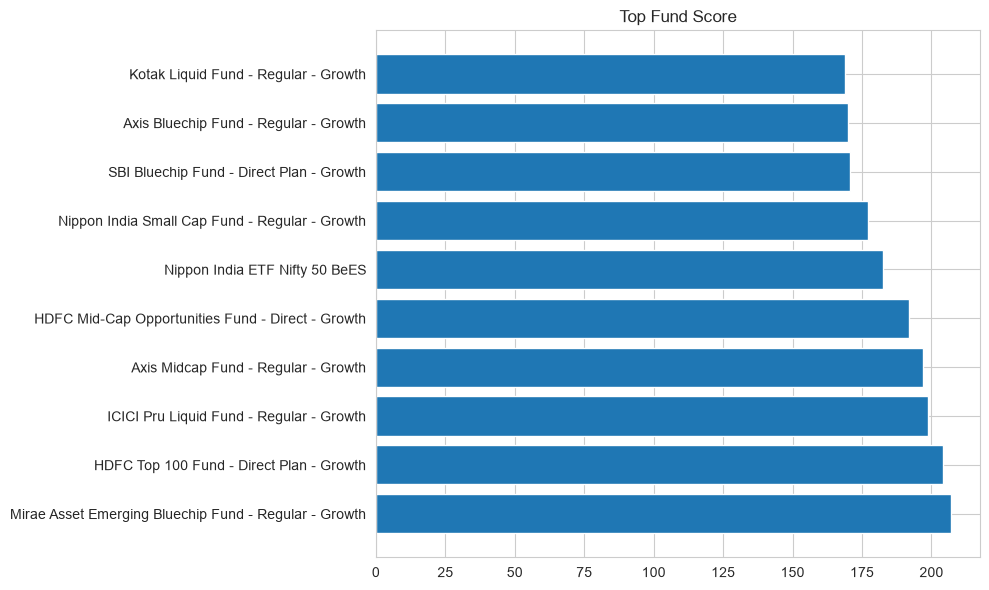

In [17]:
top = scorecard.sort_values(
"fund_score",
ascending=False
).head(10)

plt.barh(
top["scheme_name"],
top["fund_score"]
)

plt.title("Top Fund Score")

plt.tight_layout()

plt.savefig("../dashboard/charts/fund_scorecard.png")

plt.show()

In [18]:
performance[["scheme_name", "alpha", "beta"]].to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

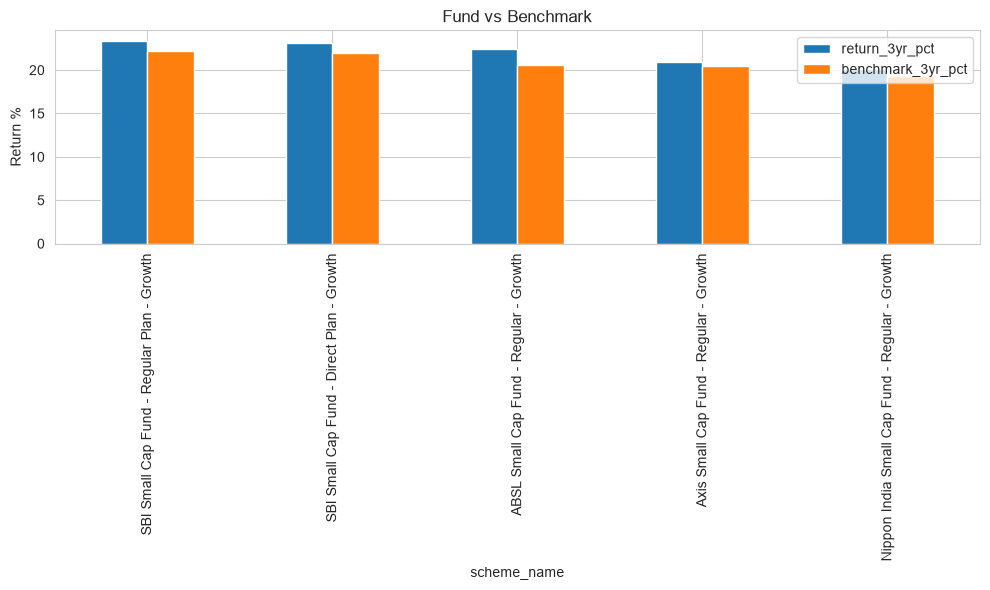

In [19]:
top5 = performance.nlargest(5, "return_3yr_pct")

comparison = top5[
    ["scheme_name", "return_3yr_pct", "benchmark_3yr_pct"]
]

comparison.set_index("scheme_name").plot(kind="bar")

plt.title("Fund vs Benchmark")

plt.ylabel("Return %")

plt.tight_layout()

plt.savefig("../dashboard/charts/benchmark_comparison.png")

plt.show()

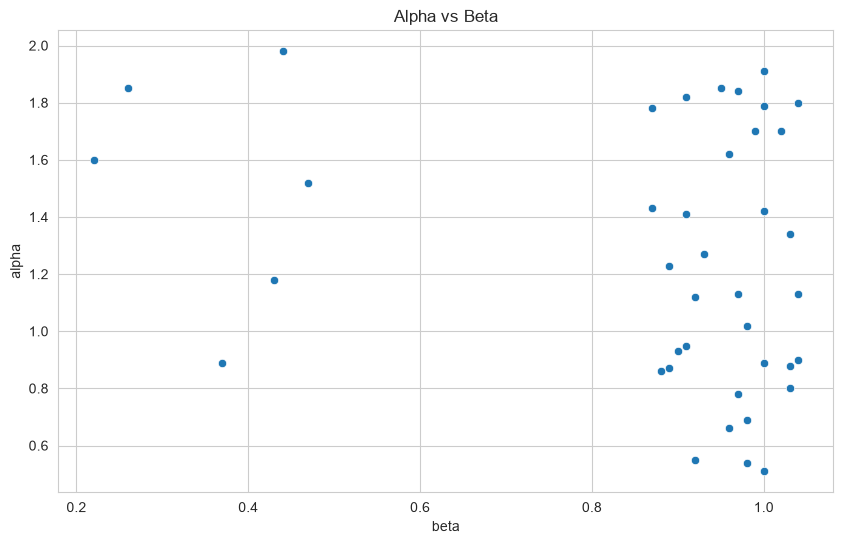

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="beta",
    y="alpha"
)

plt.title("Alpha vs Beta")

plt.savefig("../dashboard/charts/alpha_beta.png")

plt.show()